# Модуль 1. Введение в классический ML

## 5/10   Введение в градиентный спуск


### Упрощенный пример поиска максимума через расчет значения производной для одномерной функции


Исходная функция:

$f(x)=x^{2}-6 * x+5$

Производная по $х$:

$\frac{\partial f}{\partial x}=f^{\prime}(x)=2 * x-6$

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 2.305125096759656e+33 в точке -4.801171832750475e+16


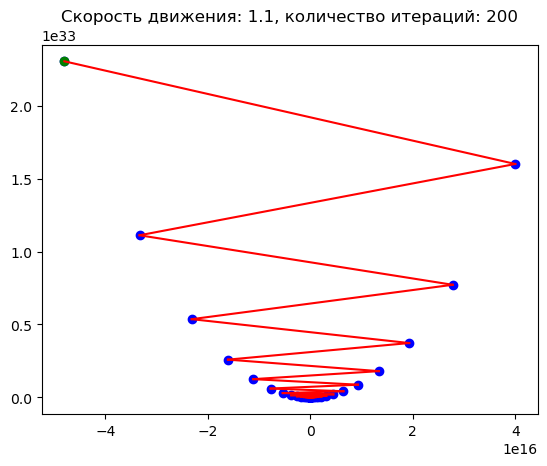

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x*x - 6*x + 5

def dfdx(x):
  return 2*x - 6

N = 200 #количество итераций
lr = 1.1 #скорость оптимизации

fig, ax = plt.subplots()
ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

x_plot = np.arange(-5, 11, 0.01)
y_plot = [f(x) for x in x_plot]
ax.plot(x_plot, y_plot)

xc = -4 #начальное значение
print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

ax.scatter(xc, f(xc), c='r')
for _ in range(N):
  x0 = xc #нужно только для графика

  xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

  ax.scatter(xc, f(xc), c='b') #нужно только для графика
  ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

ax.scatter(xc, f(xc), c='g')

print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')

plt.show()

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # <--- Важно для отображения

# 1. Функции
def f(x): return x**2 - 6*x + 5
def dfdx(x): return 2*x - 6

# 2. Подготовка данных
x_cur = 0.2
lr = 1.1
steps = 25
history_x = [x_cur]
for _ in range(steps):
    x_cur = x_cur - lr * dfdx(x_cur)
    history_x.append(x_cur)

# 3. Настройка графика
fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-300, 300, 2000)
ax.plot(x_axis, f(x_axis), color='lightgray', zorder=1)
ax.set_ylim(-500, 75000)

dot, = ax.plot([], [], 'ro', label='Спуск', zorder=3)
line, = ax.plot([], [], 'r--', alpha=0.4, zorder=2)
title = ax.set_title('')

# Скрываем создание лишнего статического графика
plt.close() 

# 4. Функция обновления
def update(i):
    curr_x_pts = history_x[:i+1]
    curr_y_pts = [f(x) for x in curr_x_pts]
    
    line.set_data(curr_x_pts, curr_y_pts)
    dot.set_data([history_x[i]], [f(history_x[i])])
    title.set_text(f'Шаг {i}: x = {history_x[i]:.2f}')
    return line, dot

# 5. Создание и отображение
ani = FuncAnimation(fig, update, frames=len(history_x), interval=300, blit=True)

# Самая важная строка для Jupyter:
HTML(ani.to_jshtml())


Начальное значение минимума: 45 в точке -4
Финальное значение минимума: -3.9999999999999982 в точке 2.9999999999999996


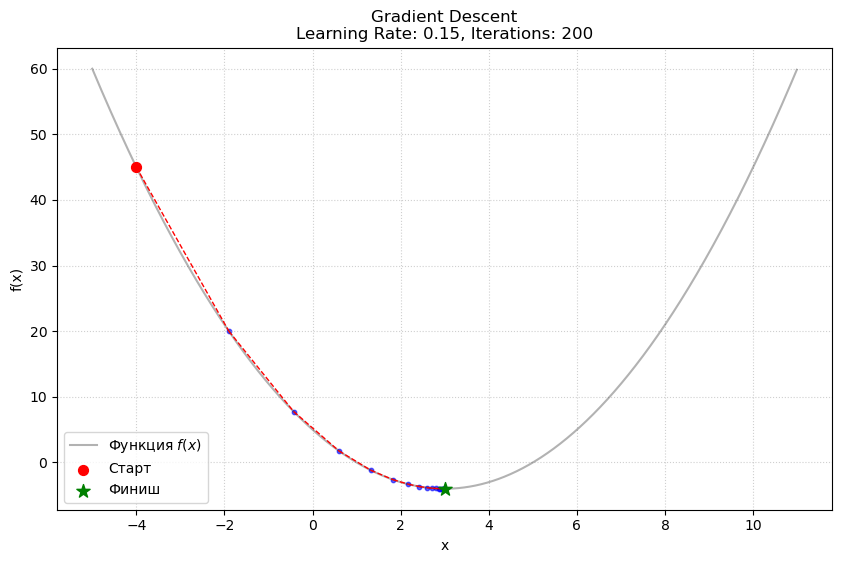

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем "полотно" (fig) и "оси" (ax) для рисования. 
# figsize=(10, 6) задает размер окна в дюймах.
fig, ax = plt.subplots(figsize=(10, 6))

# --- 1. ОТРИСОВКА ГРАФИКА ФУНКЦИИ ---
# Создаем массив чисел от -5 до 11 с шагом 0.01
x_plot = np.arange(-5, 11, 0.01)
# Вычисляем y для каждого x. 
y_plot = [f(x) for x in x_plot]
# Рисуем саму параболу. alpha=0.3 делает её полупрозрачной (фоновой), 
# чтобы она не отвлекала от шагов алгоритма.
ax.plot(x_plot, y_plot, label='Функция $f(x)$', color='black', alpha=0.3)

# --- 2. НАЧАЛЬНАЯ ТОЧКА ---
xc = -4  # Устанавливаем стартовую точку x
print(f'Начальное значение минимума: {f(xc)} в точке {xc}')
# Рисуем большую красную точку 'r' на старте. 
# zorder=5 гарантирует, что точка будет ПОВЕРХ линий.
ax.scatter(xc, f(xc), c='r', s=50, label='Старт', zorder=5)

# --- 3. ЦИКЛ ГРАДИЕНТНОГО СПУСКА ---
for i in range(N):
    x0 = xc  # Сохраняем старый x, чтобы нарисовать линию перехода
    # ГЛАВНАЯ ФОРМУЛА: делаем шаг против градиента
    xc = xc - lr * dfdx(xc)
    
    # Рисуем маленькую синюю точку 'b' в новом положении
    ax.scatter(xc, f(xc), c='b', s=10, alpha=0.6)
    # Рисуем пунктирную красную линию от старого x0 к новому xc
    ax.plot([x0, xc], [f(x0), f(xc)], c='r', linestyle='--', linewidth=1)

# --- 4. ФИНАЛЬНАЯ ТОЧКА ---
# Рисуем большую зеленую звезду 'g' в месте, где алгоритм остановился после N итераций
ax.scatter(xc, f(xc), c='g', s=100, marker='*', label='Финиш', zorder=5)

# --- ОФОРМЛЕНИЕ ---
ax.set_title(f'Gradient Descent\nLearning Rate: {lr}, Iterations: {N}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, linestyle=':', alpha=0.6) # Легкая сетка
ax.legend() # Вывод легенды (подписи "Старт", "Финиш" и т.д.)

print(f'Финальное значение минимума: {f(xc)} в точке {xc}')

plt.show()


### Создание функции для расчета

In [40]:
def gd(N, lr, min = -5, max = 11, f=f, dfdx=dfdx, xc=-4):
    """
    Реализация и визуализация процедуры градиентного спуска 
    для конкретной функции в упрощенном примере.

    Parameters
    ----------
    N: integer
        Число шагов градиентного спуска, которые необходимо выполнить.
      
    lr: float
        Скорость обучения
    
    min: float
        Минимальное значение, отображаемое на графике
      
    max: float
        Максимальное значение, отображаемое на графике
    
    f: function
        Целевая функция
    
    dfdx: function
        Градиент целевой функции

    Returns
    ----------
    """
    fig, ax = plt.subplots()
    ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

    x_plot = np.arange(min, max, 0.01)
    y_plot = [f(x) for x in x_plot]
    ax.plot(x_plot, y_plot)
  
    print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

    ax.scatter(xc, f(xc), c='r')

    for _ in range(N):
      x0 = xc #нужно только для графика

      xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

      ax.scatter(xc, f(xc), c='b') #нужно только для графика
      ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

    ax.scatter(xc, f(xc), c='g')

    print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')
    plt.show()

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 45 в точке -4


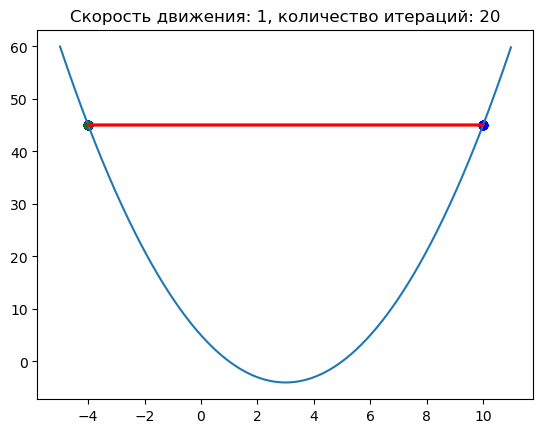

In [41]:
gd(20, 1, min=-5, max = 11)


Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.919295494677521


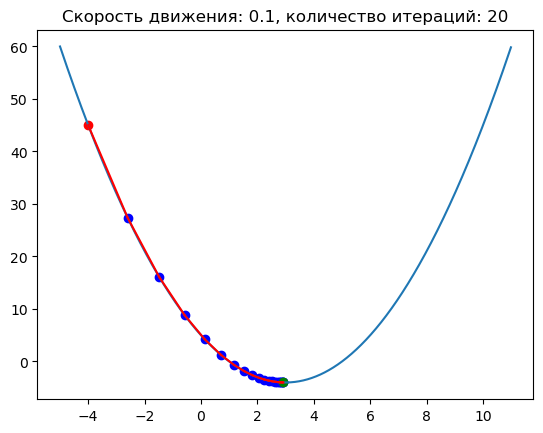

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


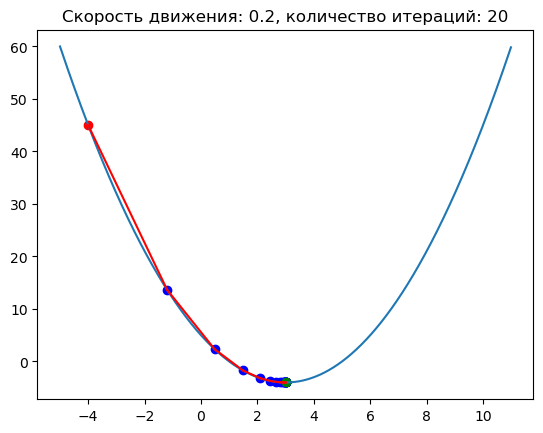

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


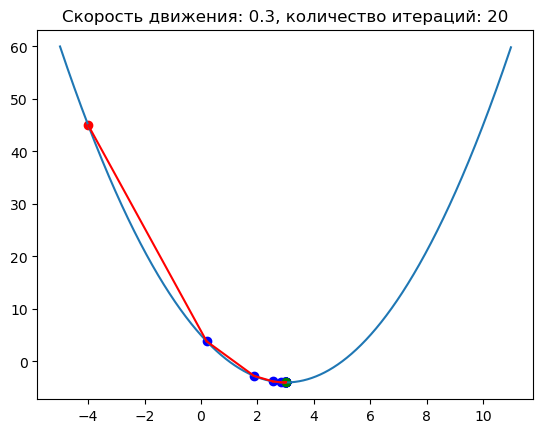

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


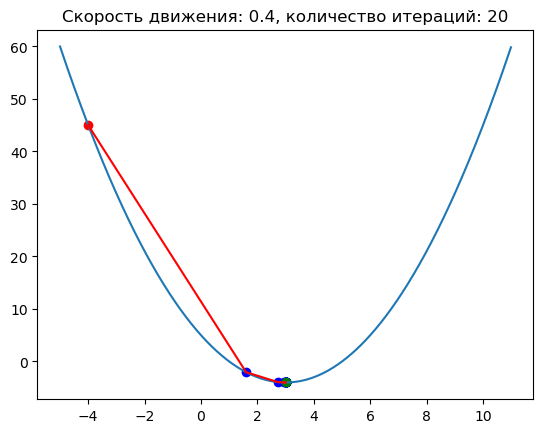

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 3.0


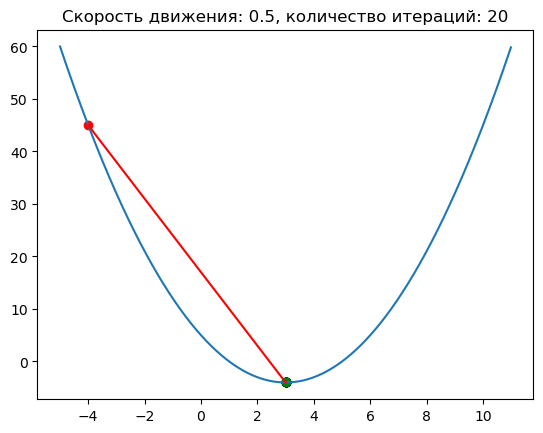

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


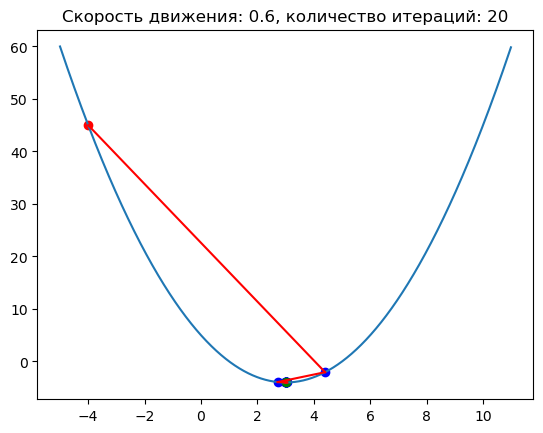

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


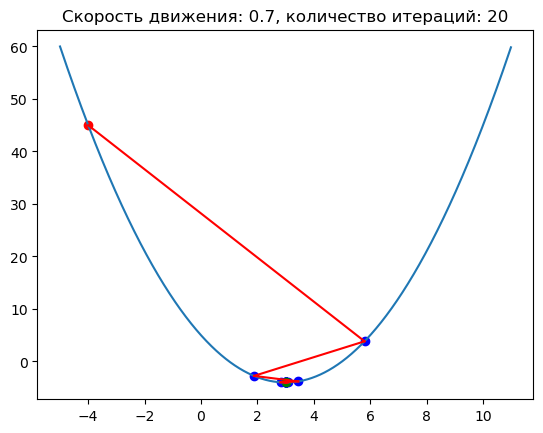

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


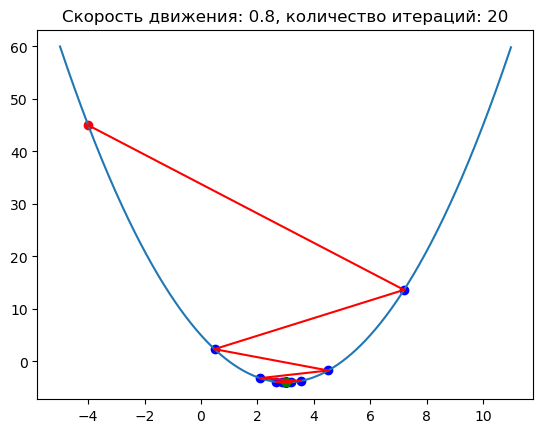

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.9192954946775207


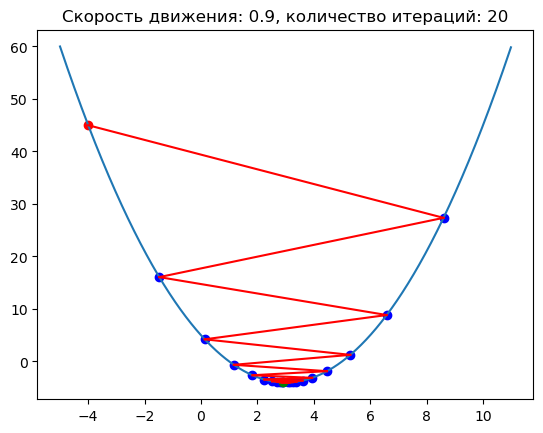

In [47]:
for i in range(1, 10):
  gd(N=20, lr=i/10)

## 6/10   Сложности оптимизации (локальные минимумы)


Рассмотрим более сложную функцию, чем во втором уроке:

$f_{2}(x)=x^{2}+15 * \sin (x)$

$f_{2}^{\prime}(x)=2 * x+15 * \cos (x)$

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def f2(x):
  return x*x + 15*np.sin(x)

def df2dx(x):
  return 2*x + 15*np.cos(x)

Начальное значение минимумума: 91.83968333665945 в точке 10
Финальное значение минимумума: 4.529631081084053 в точке 4.129334334768743


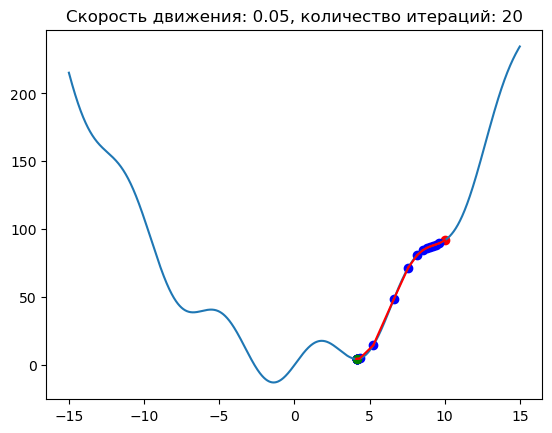

In [49]:
gd(20, 0.05, min=-15, max= 15, f=f2, dfdx=df2dx, xc=10)


Начальное значение минимумума: 39.38386411994708 в точке -5
Финальное значение минимумума: -12.823616841551932 в точке -1.3851303718795267


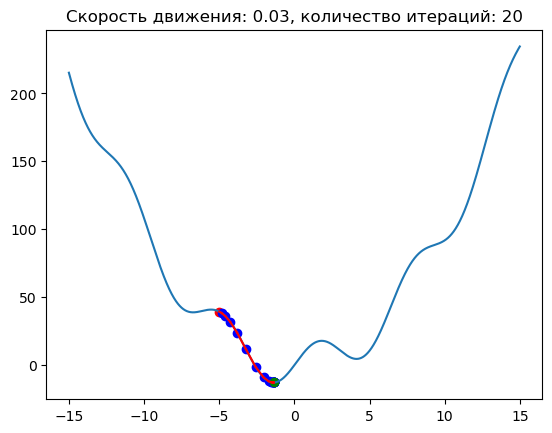

In [50]:
gd(20, 0.03, min=-15, max= 15, f=f2, dfdx=df2dx, xc=-5)


## 8/10   Градиентный спуск в машинном обучении (практическая часть)


In [51]:
from copy import deepcopy # лучший модуль для обеспечения реального копирования объектов
from tqdm import tqdm # библиотека для создания шкалы прогресса итерационного процесса

import seaborn
import numpy as np
import matplotlib.pyplot as plt

Сгенерируем данные $x$ — вектора признаков и $y$ — вектора значений целевой переменной:

In [52]:
std_error = 30 # коэффициент который нужен для генерации случайных данных в разбросе
sample_size = 10000 # размер выборки
theta0, theta1 = 1, 10 # параметры функции, описанной выше

x = np.random.randn(sample_size) # генерация случайной выборки
func_y = lambda x: theta0 + theta1 * x # лямбда-функция для расчета значений функции

y = func_y(x) + std_error * np.random.randn(sample_size) # расчет значений выборки с учетом случайного разброса

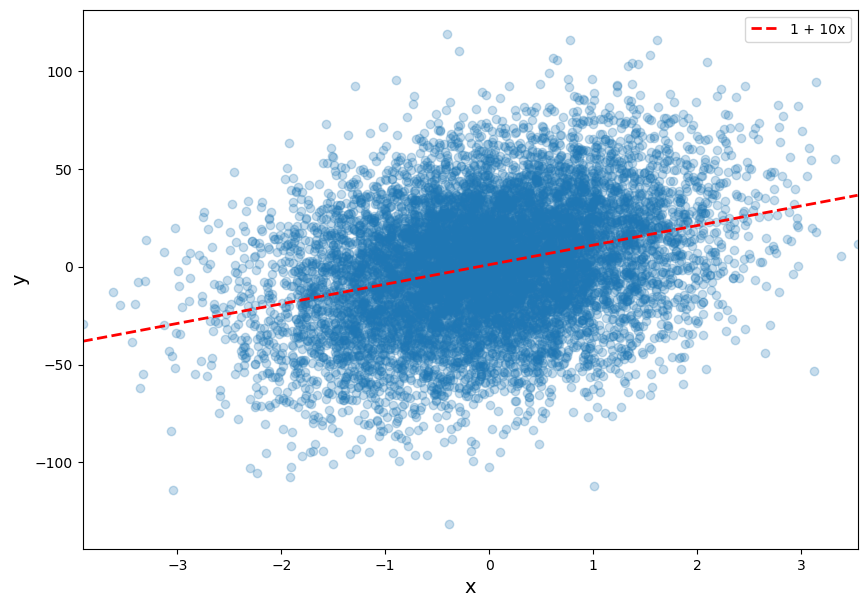

In [53]:
x_plot = np.linspace(x.min(), x.max(), 1000) 
y_plot = func_y(x_plot)

fig = plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_plot, y_plot, "r--", linewidth=2, label=f"{theta0} + {theta1}x")
plt.xlim(x.min(), x.max())
plt.xlabel("x", size=14)
plt.ylabel("y", size=14)
plt.legend(loc="best")

plt.show()

In [57]:
def calculate_predictions(theta0, theta1, X):
    """
    Вычисление значения функции для заданных коэффициентов и значений X.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, ]
        Вектор признаков.

    Returns
    -------
    y_pred: array-like, shape = [n_samples, ]
        Полученное значение функции.

    """
    return theta0 + theta1*X
    

def calculate_cost(theta0, theta1, X, y):
    """
    Вычисление значения функции потерь.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    Returns
    -------
    cost: float
        Значение функции потерь.

    """
    theta0 = np.atleast_3d(np.asarray(theta0)) # перевод значений коэффициентов в удобный для работы программы вид
    theta1 = np.atleast_3d(np.asarray(theta1))

    y_pred = calculate_predictions(theta0, theta1, X)
    cost = np.average((y - y_pred)**2, axis=2)/2

    return cost


def gradient_descent_step(theta, X, y, learning_rate):
    """
    Один шаг градиентного спуска.

    Parameters
    ----------
    theta: array-like
        Массив значений параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    learning_rate: float
        Скорость обучения.

    Returns
    -------
    updated_theta: array-like
        Обновленный массив значений параметров theta.

    """
    n = len(y)
    y_pred = calculate_predictions(theta[0], theta[1], X)

    updated_theta = deepcopy(theta)
    updated_theta[0] -= learning_rate / n * np.sum((y_pred - y))
    updated_theta[1] -= learning_rate / n * np.sum((y_pred - y) * X)

    return updated_theta

    
def plot_gradient_descent(cost_history, theta_history, X, y):
    """
    Parameters
    ----------
    cost_history: list[float]
        Список со значениями функции потерь на каждой
        итерации обучения.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    """
    fig = plt.figure(figsize=(15, 15))
    plt.subplot(221)
    plt.scatter(range(len(cost_history)), cost_history)
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"J($\theta$)", size=14)

    plt.subplot(223)
    plt.scatter(x, y, alpha=0.15)
    x_plot = np.linspace(-3, 3, 500)
    for num, theta in enumerate(theta_history):
        y_plot = calculate_predictions(theta[0], theta[1], x_plot)
        if num == 0:
            plt.plot(x_plot, y_plot, color="green", label="Стартовая линия - baseline", linewidth=5)
        if num == len(theta_history) - 1:
            plt.plot(x_plot, y_plot, color="orange", label="Реузльтат работы", linewidth=5)
        else:
            plt.plot(x_plot, y_plot, "r--", alpha=.5)
    plt.xlim(x_plot.min(), x_plot.max())
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)
    plt.plot(x_plot, func_y(x_plot), color = "black", label="Исходная линия", linewidth=3)
    plt.legend(loc="best")

    plt.subplot(222)
    x_plot = range(len(cost_history)+1)
    plt.scatter(x_plot, [theta[0] for theta in theta_history], label=r'$\theta_0$')
    plt.scatter(x_plot, [theta[1] for theta in theta_history], label=r'$\theta_1$')
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"$\theta$", size=14)
    plt.legend(loc="best")
    plt.subplot(224)
    plot_cost_function(X, y, theta_history)


def plot_cost_function(X, y, theta_history):
    """
    Визуализация процесса градиетного спуска и
    построение линий уровня.

    Parameters
    ----------
    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    """
    theta0 = [theta[0] for theta in theta_history]
    theta1 = [theta[1] for theta in theta_history]

    #theta0_grid = np.linspace(-5*min(theta0), max(theta0), 200)
    #theta1_grid = np.linspace(-5*min(theta1), max(theta1), 200)
    theta0_grid = np.linspace(-25, 25, 200)
    theta1_grid = np.linspace(-25, 25, 200)
    cost_grid = calculate_cost(
        theta0_grid[np.newaxis,:,np.newaxis],
        theta1_grid[:,np.newaxis,np.newaxis],
        X, y
    )
    X, Y = np.meshgrid(theta0_grid, theta1_grid)

    theta0, theta1 = theta_history[-1]
    plt.scatter([theta0]*2, [theta1]*2, s=[50, 0], color=['k','w'])
    contours = plt.contour(X, Y, cost_grid, 30)
    plt.clabel(contours)

    for it in range(1, len(theta_history)):
        plt.annotate(
            '', xy=theta_history[it], xytext=theta_history[it-1],
            arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
            va='center', ha='center'
        )

    plt.scatter(*zip(*theta_history), color="black", s=40, lw=0)
    plt.xlim(theta0_grid.min(), theta0_grid.max())
    plt.ylim(theta1_grid.min(), theta1_grid.max())
    plt.xlabel(r'$\theta_0$', size=15)
    plt.ylabel(r'$\theta_1$', size=15)
    plt.title('Функция потерь', size=15)

In [58]:
n_iterations, learning_rate = 100, 0.5
theta_history, cost_history = [100*np.random.rand(2)], []

for it in tqdm(range(n_iterations)):
    last_theta = theta_history[-1]
    current_theta = gradient_descent_step(
        theta=last_theta, X=x, y=y, learning_rate=learning_rate
    )
    theta_history.append(current_theta)
    cost_history.append(calculate_cost(current_theta[0], current_theta[1], X=x, y=y))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4529.05it/s]


MemoryError: Unable to allocate 2.98 GiB for an array with shape (200, 200, 10000) and data type float64

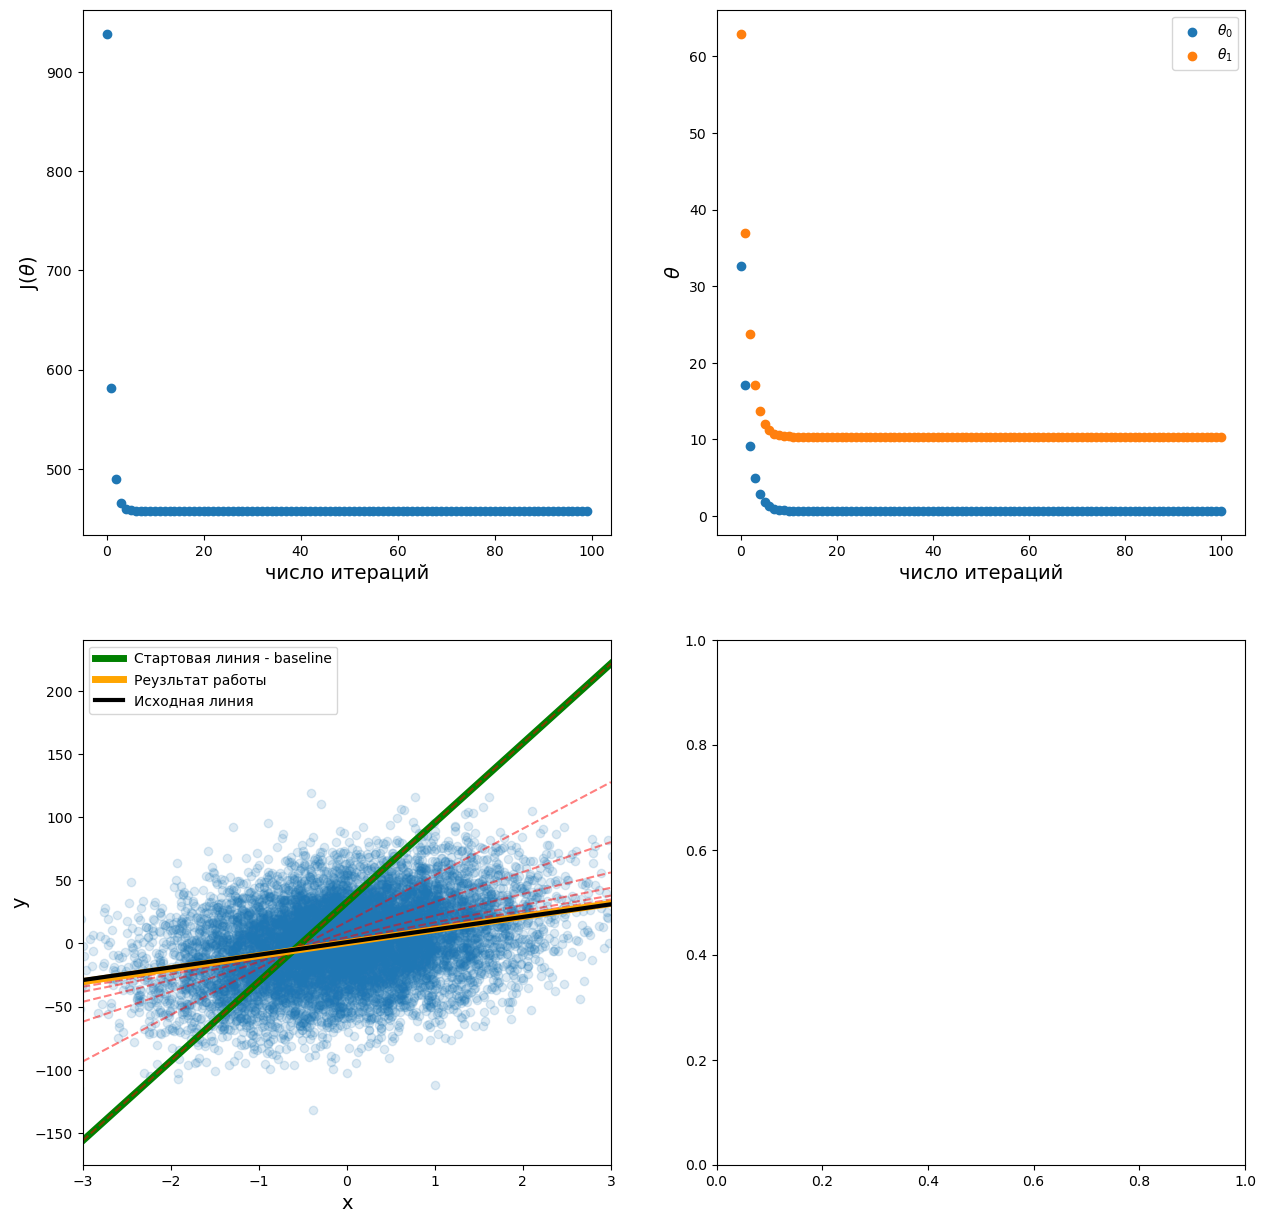

In [59]:
plot_gradient_descent(
    cost_history=cost_history,
    theta_history=theta_history,
    X=x, y=y
)